# Cycle-CNN: Unsupervised Remote Sensing Image Super-Resolution
**Paper:** Wang et al., IGARSS 2019 — *Unsupervised Remote Sensing Image Super-Resolution Using Cycle CNN*

This notebook is **fully self-contained** — just run every cell top to bottom.  
The dataset (**STL-10**) downloads automatically on first run (~2.6 GB, stored in `data/`).

### What is trained
Two CNNs are trained in a **cycle** with *unpaired* LR / HR image patches:

| Generator | Direction | Scale | ResBlocks |
|---|---|---|---|
| **G1** | LR (96×96) → HR (384×384) | ×4 | 16 |
| **G2** | HR (384×384) → LR (96×96) | ÷4 | 5 |

### Loss functions
$$L_{\text{total}} = 2 \cdot L_{\text{cyc}} + 1 \cdot L_{\text{idt}}$$

$$L_{\text{cyc}} = \frac{1}{N}\sum\!\left[\|G_2(G_1(x_t)) - x_t\|_2 + \|G_1(G_2(y_t)) - y_t\|_2\right]$$

$$L_{\text{idt}} = \frac{1}{N}\sum\|G_1(y_t{\downarrow_4}) - y_t\|_2$$


In [1]:
# ── Cell 1: Install & import ───────────────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs, extra_index=None):
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', *pkgs]
    if extra_index:
        cmd += ['--index-url', extra_index]
    subprocess.check_call(cmd)

# ── Step 1: Ensure CUDA-enabled PyTorch is installed ──────────────────────────
# Plain "pip install torch" gives CPU-only builds.
# We must use the official CUDA index URL to get GPU support.
try:
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('CPU-only torch detected — reinstalling with CUDA support.')
    print(f'torch {torch.__version__} already installed with CUDA support.')
except (ImportError, RuntimeError) as e:
    print(f'{e}')
    print('Installing CUDA-enabled PyTorch (cu121)...')
    pip_install('torch', 'torchvision',
                extra_index='https://download.pytorch.org/whl/cu121')
    import torch

# ── Step 2: Install other packages if needed ──────────────────────────────────
try:
    import torchvision, numpy, PIL, scipy, skimage, matplotlib
except ImportError:
    pip_install('torchvision', 'numpy', 'Pillow', 'scipy', 'scikit-image', 'matplotlib')
    import torchvision, numpy, PIL, scipy, skimage, matplotlib

# ── Step 3: Core imports ──────────────────────────────────────────────────────
import math, os, random, time, glob
from pathlib import Path
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from scipy.ndimage import gaussian_filter
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# ── Step 4: Device selection — must be CUDA ───────────────────────────────────
if not torch.cuda.is_available():
    print('\n⚠  WARNING: CUDA still not available after installation.')
    print('   Possible causes:')
    print('   1. Your CUDA driver is older than 12.1 — try cu118:')
    print('      pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118')
    print('   2. The wrong kernel is selected — check VS Code kernel picker (top-right)')
    print('      and select the same Python that main.ipynb uses.')
    DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cuda')
    torch.backends.cudnn.benchmark = True    # speed up fixed-size convolutions

print(f'\nPyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}'
      + (f'  ←  {torch.cuda.get_device_name(0)}'
         f'  |  {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB VRAM'
         if torch.cuda.is_available() else '  ←  CPU only'))

torch 2.6.0+cu124 already installed with CUDA support.

PyTorch : 2.6.0+cu124
Device  : cuda  ←  NVIDIA GeForce RTX 4060 Laptop GPU  |  8.0 GB VRAM


## 1 — Model Definitions (G1, G2, SRCNN)

In [2]:
# ── ResBlock ──────────────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    """Conv→BN→ReLU→Conv→BN with identity skip (used in both G1 and G2)."""
    def __init__(self, ch=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False), nn.BatchNorm2d(ch),
        )
    def forward(self, x): return x + self.body(x)


# ── SubpixelConv: Conv(3×3,256) → PixelShuffle(2) → ReLU  (×2 upsample) ──────
class SubpixelConv(nn.Module):
    def __init__(self, in_ch=64):
        super().__init__()
        self.conv    = nn.Conv2d(in_ch, 256, 3, 1, 1)   # 256 = 64 × 2²
        self.shuffle = nn.PixelShuffle(2)                # → 64ch, 2×spatial
        self.relu    = nn.ReLU(True)
    def forward(self, x): return self.relu(self.shuffle(self.conv(x)))


# ── G1: LR (96×96) → HR (384×384), ×4 super-resolution ──────────────────────
class G1(nn.Module):
    def __init__(self, n_res=16):
        super().__init__()
        self.head     = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(True),
        )
        self.resblocks = nn.Sequential(*[ResBlock(64) for _ in range(n_res)])
        self.post_res  = nn.Conv2d(64, 64, 3, 1, 1)
        self.up1       = SubpixelConv(64)   # 96  → 192
        self.up2       = SubpixelConv(64)   # 192 → 384
        self.tail      = nn.Conv2d(64, 1, 3, 1, 1)

    def forward(self, x):
        f = self.head(x)
        f = self.post_res(self.resblocks(f)) + f   # global skip
        f = self.up2(self.up1(f))
        return torch.clamp(self.tail(f), 0., 255.)


# ── G2: HR (384×384) → LR (96×96), ×4 down-sampling ─────────────────────────
class G2(nn.Module):
    def __init__(self, n_res=5):
        super().__init__()
        self.pool      = nn.Sequential(nn.AvgPool2d(2), nn.AvgPool2d(2))   # ÷4
        self.head      = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(True),
        )
        self.resblocks = nn.Sequential(*[ResBlock(64) for _ in range(n_res)])
        self.tail      = nn.Sequential(
            nn.Conv2d(64, 64, 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(64, 1, 3, 1, 1),
        )

    def forward(self, x):
        x = self.pool(x)
        return torch.clamp(self.tail(self.resblocks(self.head(x))), 0., 255.)


# ── SRCNN baseline (Dong et al., 2016) ───────────────────────────────────────
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 9, padding=4), nn.ReLU(True),
            nn.Conv2d(64, 32, 1),           nn.ReLU(True),
            nn.Conv2d(32, 1, 5, padding=2),
        )
    def forward(self, x): return torch.clamp(self.net(x), 0., 255.)


def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

# ── Quick shape check ─────────────────────────────────────────────────────────
_g1, _g2 = G1().to(DEVICE), G2().to(DEVICE)
_lr, _hr  = torch.zeros(1,1,96,96,device=DEVICE), torch.zeros(1,1,384,384,device=DEVICE)
with torch.no_grad():
    _sr, _dn = _g1(_lr), _g2(_hr)
assert _sr.shape == (1,1,384,384) and _dn.shape == (1,1,96,96), 'Shape mismatch!'

print(f'G1 (SR):      {count_params(_g1):>10,} params  |  output {tuple(_sr.shape)}  ✓')
print(f'G2 (Downsmp): {count_params(_g2):>10,} params  |  output {tuple(_dn.shape)}  ✓')
print(f'SRCNN:        {count_params(SRCNN()):>10,} params')

G1 (SR):       1,554,241 params  |  output (1, 1, 384, 384)  ✓
G2 (Downsmp):    444,993 params  |  output (1, 1, 96, 96)  ✓
SRCNN:             8,129 params


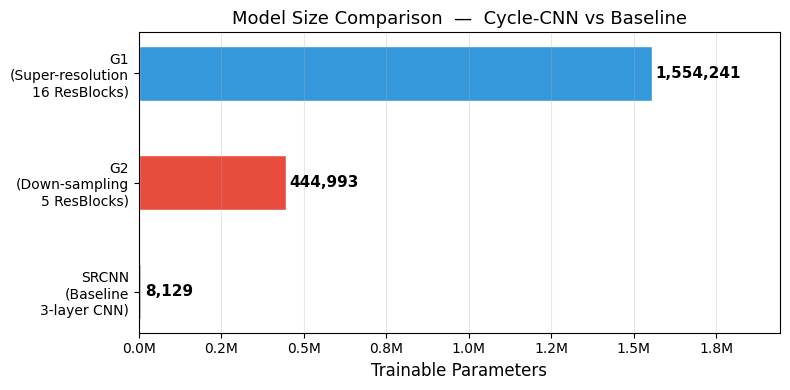

In [3]:
# ── Model parameter comparison ────────────────────────────────────────────────
models_info = {
    'G1\n(Super-resolution\n16 ResBlocks)': count_params(_g1),
    'G2\n(Down-sampling\n5 ResBlocks)': count_params(_g2),
    'SRCNN\n(Baseline\n3-layer CNN)': count_params(SRCNN()),
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(list(models_info.keys()), list(models_info.values()),
               color=['#3498db', '#e74c3c', '#95a5a6'], edgecolor='white', height=0.5)
for bar, val in zip(bars, models_info.values()):
    ax.text(bar.get_width() + 10_000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Trainable Parameters', fontsize=12)
ax.set_title('Model Size Comparison  —  Cycle-CNN vs Baseline', fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax.set_xlim(0, max(models_info.values()) * 1.25)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 2 — Loss Functions & Utilities

In [4]:
# ── Loss functions (paper equations 1-4) ──────────────────────────────────────

def cycle_loss(x_t, x_rec, y_t, y_rec):
    """L_cyc = MSE(G2(G1(x_t)), x_t) + MSE(G1(G2(y_t)), y_t)"""
    return F.mse_loss(x_rec, x_t) + F.mse_loss(y_rec, y_t)

def identity_loss(y_t, y_t_sr):
    """L_idt = MSE(G1(bicubic_down(y_t)), y_t)"""
    return F.mse_loss(y_t_sr, y_t)

def total_loss(l_cyc, l_idt, w1=2., w2=1.):
    """L_total = w1*L_cyc + w2*L_idt   (paper: w1=2, w2=1)"""
    return w1 * l_cyc + w2 * l_idt

def bicubic_down4(t):
    """4× bicubic downsample via F.interpolate."""
    return F.interpolate(t, scale_factor=0.25, mode='bicubic',
                         align_corners=False, antialias=True)

# ── Metric helpers ─────────────────────────────────────────────────────────────

def to_np(t):
    """(1,H,W) or (1,1,H,W) tensor → (H,W) uint8 numpy."""
    return np.clip(t.detach().cpu().float().squeeze().numpy(), 0, 255).astype(np.uint8)

def calc_psnr(sr, hr):
    sr8, hr8 = np.clip(sr,0,255).astype(np.uint8), np.clip(hr,0,255).astype(np.uint8)
    return peak_signal_noise_ratio(hr8, sr8, data_range=255)

def calc_ssim(sr, hr):
    sr8, hr8 = np.clip(sr,0,255).astype(np.uint8), np.clip(hr,0,255).astype(np.uint8)
    return structural_similarity(hr8, sr8, data_range=255)

# ── Checkpoint helpers ─────────────────────────────────────────────────────────

def save_ckpt(g1, g2, opt, it, loss, ckpt_dir='checkpoints'):
    Path(ckpt_dir).mkdir(parents=True, exist_ok=True)
    path = f'{ckpt_dir}/ckpt_{it:07d}.pth'
    torch.save({'it': it, 'g1': g1.state_dict(), 'g2': g2.state_dict(),
                'opt': opt.state_dict(), 'loss': loss}, path)
    print(f'[ckpt] saved → {path}')

def load_ckpt(path, g1, g2=None, opt=None):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
    g1.load_state_dict(ckpt['g1'])
    if g2  is not None: g2.load_state_dict(ckpt['g2'])
    if opt is not None: opt.load_state_dict(ckpt['opt'])
    print(f'[ckpt] loaded iter {ckpt["it"]} ← {path}')
    return ckpt['it']

print('Loss functions and utilities defined.')

Loss functions and utilities defined.


## 3 — Dataset (Auto-Download)

| Split used | Role | Size |
|---|---|---|
| `unlabeled` first 50 000 images | **HR** training patches (resized to 384×384) | 96×96 → 384×384 |
| `unlabeled` last 50 000 images | **LR** training patches (Y channel, 96×96) | 96×96 |
| `train` split (5 000 images) | Test set (paired evaluation) | 96×96 |

Because LR and HR come from **different** images, the training is truly **unpaired**.

In [5]:
# ── STL-10 Dataset wrapper ────────────────────────────────────────────────────
# STL-10 is auto-downloaded via torchvision (download=True).
# Images are 96×96 RGB.  We convert to Y-channel (grayscale luminance).

DATA_ROOT  = 'data'
LR_PATCH   = 96    # paper: crop 96×96 from 256×256 LR images
HR_PATCH   = 384   # paper: crop 384×384 from 1024×1024 HR images
BATCH_SIZE = 8

def rgb_to_y(img_pil):
    """PIL RGB image → Y-channel float32 numpy (0–255)."""
    if img_pil.mode != 'RGB':
        img_pil = img_pil.convert('RGB')
    y, _, _ = img_pil.convert('YCbCr').split()
    return np.array(y, dtype=np.float32)

def rand_crop(arr, size):
    """Random crop of (size × size) from a 2-D float32 numpy array."""
    h, w = arr.shape
    if h < size:
        arr = np.array(Image.fromarray(arr.astype(np.uint8)).resize(
                           (max(w, size), size), Image.BICUBIC), dtype=np.float32)
        h, w = arr.shape
    if w < size:
        arr = np.array(Image.fromarray(arr.astype(np.uint8)).resize(
                           (size, max(h, size)), Image.BICUBIC), dtype=np.float32)
        h, w = arr.shape
    top  = random.randint(0, h - size)
    left = random.randint(0, w - size)
    patch = arr[top:top+size, left:left+size]
    return torch.from_numpy(patch).unsqueeze(0)   # (1, size, size)


class STL10PairedDataset(Dataset):
    """
    Uses STL-10 for self-supervised SR evaluation.
    Each item: original 96×96 image = LR,  4× bicubic upscale = HR reference.
    This gives proper paired PSNR/SSIM numbers on the test set.
    """
    def __init__(self, root, split='train', max_images=200):
        ds = torchvision.datasets.STL10(root=root, split=split, download=True)
        self.images = [ds[i][0] for i in range(min(len(ds), max_images))]

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        y = rgb_to_y(self.images[idx])                 # (96, 96)
        lr_t = torch.from_numpy(y).unsqueeze(0)         # (1, 96, 96)
        # Bicubic 4× upsample → HR reference (384×384)
        hr_t = F.interpolate(lr_t.unsqueeze(0), scale_factor=4,
                             mode='bicubic', align_corners=False,
                             antialias=True).squeeze(0).clamp(0, 255)
        return lr_t, hr_t


class STL10UnpairedDataset(Dataset):
    """
    Unpaired training dataset built from STL-10 unlabeled split.
    - HR patches: random 384×384 crop of a 4× bicubic upscaled STL-10 image
                  (uses indices 0 … N//2)
    - LR patches: random  96×96 crop from a *different* STL-10 image
                  (uses indices N//2 … N)
    Because LR and HR come from different images the training is truly unpaired.
    """
    def __init__(self, root, max_images=2000, split='unlabeled'):
        ds = torchvision.datasets.STL10(root=root, split=split, download=True)
        n  = min(len(ds), max_images)
        half = n // 2
        # Pre-load Y arrays to RAM  (STL-10 unlabeled = 100k images;
        # clamp max_images for smoke-testing)
        print(f'Loading {n} STL-10 images for unpaired training...')
        self.hr_imgs = [rgb_to_y(ds[i][0]) for i in range(half)]
        self.lr_imgs = [rgb_to_y(ds[i][0]) for i in range(half, n)]
        print(f'  HR pool: {len(self.hr_imgs)} images | LR pool: {len(self.lr_imgs)} images')

    def __len__(self): return max(len(self.hr_imgs), len(self.lr_imgs))

    def __getitem__(self, idx):
        hr_idx = idx % len(self.hr_imgs)
        lr_idx = idx % len(self.lr_imgs)
        # HR: bicubic upsample 96→384, then random crop
        hr_np = rgb_to_y(Image.fromarray(self.hr_imgs[hr_idx].astype(np.uint8)).resize(
                         (384, 384), Image.BICUBIC))
        hr_patch = rand_crop(hr_np, HR_PATCH)   # (1,384,384)
        lr_patch = rand_crop(self.lr_imgs[lr_idx], LR_PATCH)  # (1,96,96)
        return lr_patch, hr_patch


# ── Build DataLoaders ──────────────────────────────────────────────────────────
# max_images controls RAM usage during demo; raise to 10000+ for real training.
MAX_TRAIN_IMAGES = 500   # ← increase for real training (e.g. 10000)
MAX_TEST_IMAGES  = 64

# pin_memory=True speeds up CPU→GPU transfer on CUDA devices
_pin = torch.cuda.is_available()

train_ds = STL10UnpairedDataset(DATA_ROOT, max_images=MAX_TRAIN_IMAGES)
test_ds  = STL10PairedDataset(DATA_ROOT,   max_images=MAX_TEST_IMAGES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, drop_last=True, pin_memory=_pin)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=0, pin_memory=_pin)

lr_b, hr_b = next(iter(train_loader))
print(f'\nTrain — LR batch: {tuple(lr_b.shape)},  HR batch: {tuple(hr_b.shape)}')
print(f'Test  — {len(test_ds)} paired images')
print(f'pin_memory : {_pin}  (True = faster CPU→GPU transfer)')

Loading 500 STL-10 images for unpaired training...
  HR pool: 250 images | LR pool: 250 images

Train — LR batch: (8, 1, 96, 96),  HR batch: (8, 1, 384, 384)
Test  — 64 paired images
pin_memory : True  (True = faster CPU→GPU transfer)


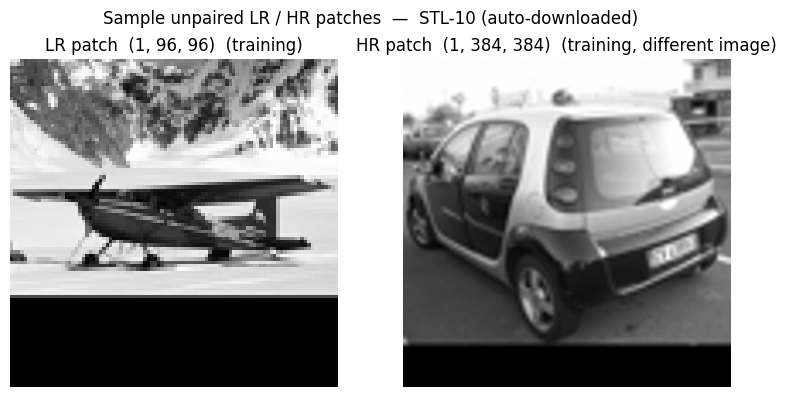

In [6]:
# ── Visualise a sample LR / HR pair from the training set ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(lr_b[0, 0].numpy(), cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'LR patch  {tuple(lr_b[0].shape)}  (training)')
axes[0].axis('off')
axes[1].imshow(hr_b[0, 0].numpy(), cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'HR patch  {tuple(hr_b[0].shape)}  (training, different image)')
axes[1].axis('off')
plt.suptitle('Sample unpaired LR / HR patches  —  STL-10 (auto-downloaded)')
plt.tight_layout(); plt.show()

## 4 — Training Loop

In [7]:
def train_cycle_cnn(
    g1, g2,
    train_loader, test_loader,
    total_iters   = 180_000,
    lr_init       = 1e-4,
    lr_decay_iter = 90_000,
    log_every     = 100,
    val_every     = 5_000,
    ckpt_every    = 10_000,
    ckpt_dir      = 'checkpoints',
):
    """
    Full Cycle-CNN training loop (paper: Wang et al., IGARSS 2019).
    Returns: loss_log, iter_log, cyc_log, idt_log, psnr_log, psnr_iter_log
    """
    dev = next(g1.parameters()).device
    if str(dev) == 'cpu':
        print('⚠  Models are on CPU. Training will be very slow.')
        print('   Re-run Cell 1 to install CUDA PyTorch, then restart the kernel.')
    else:
        mem = torch.cuda.get_device_properties(dev).total_memory / 1024**3
        print(f'✓  Training on {dev}  ({torch.cuda.get_device_name(dev)}, {mem:.1f} GB VRAM)')

    optimizer = optim.Adam(
        list(g1.parameters()) + list(g2.parameters()),
        lr=lr_init, betas=(0.9, 0.999), eps=1e-8,
    )
    g1.train(); g2.train()

    loss_log, iter_log = [], []   # total loss
    cyc_log,  idt_log  = [], []   # individual components
    psnr_log, psnr_iter_log = [], []  # validation PSNR checkpoints

    loader_iter = iter(train_loader)
    t0 = time.time()

    for it in range(1, total_iters + 1):

        if it == lr_decay_iter:
            for pg in optimizer.param_groups: pg['lr'] *= 0.1
            print(f'[{it}] LR → {optimizer.param_groups[0]["lr"]:.1e}')

        try:
            x_t, y_t = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            x_t, y_t = next(loader_iter)
        x_t = x_t.to(DEVICE, non_blocking=True)
        y_t = y_t.to(DEVICE, non_blocking=True)

        y_fake = g1(x_t);  x_rec = g2(y_fake)
        x_fake = g2(y_t);  y_rec = g1(x_fake)
        y_t_sr = g1(bicubic_down4(y_t))

        l_cyc = cycle_loss(x_t, x_rec, y_t, y_rec)
        l_idt = identity_loss(y_t, y_t_sr)
        l_tot = total_loss(l_cyc, l_idt)

        optimizer.zero_grad(); l_tot.backward(); optimizer.step()

        if it % log_every == 0:
            loss_log.append(l_tot.item())
            cyc_log.append(l_cyc.item())
            idt_log.append(l_idt.item())
            iter_log.append(it)

            val_psnr_str = ''
            if it % val_every == 0:
                g1.eval()
                psnrs = []
                with torch.no_grad():
                    for lr_v, hr_v in test_loader:
                        sr_v = g1(lr_v.to(DEVICE, non_blocking=True))
                        psnrs.append(calc_psnr(to_np(sr_v), to_np(hr_v)))
                        if len(psnrs) >= 8: break
                avg_psnr = sum(psnrs) / len(psnrs)
                psnr_log.append(avg_psnr)
                psnr_iter_log.append(it)
                val_psnr_str = f'  val_PSNR={avg_psnr:.2f}dB'
                g1.train()

            elapsed = (time.time() - t0) / 60
            print(f'[{it:6d}/{total_iters}]  '
                  f'Loss={l_tot.item():.3f}  '
                  f'Cyc={l_cyc.item():.3f}  '
                  f'Idt={l_idt.item():.3f}'
                  + val_psnr_str + f'  ({elapsed:.1f}min)')

        if it % ckpt_every == 0:
            save_ckpt(g1, g2, optimizer, it, l_tot.item(), ckpt_dir)

    save_ckpt(g1, g2, optimizer, total_iters, loss_log[-1] if loss_log else 0., ckpt_dir)
    print(f'Training done in {(time.time()-t0)/60:.1f} min.')
    return loss_log, iter_log, cyc_log, idt_log, psnr_log, psnr_iter_log

print('train_cycle_cnn() defined.')

train_cycle_cnn() defined.


## 5 — Run: Smoke-Test (500 iterations)

This verifies the full pipeline works end-to-end.  
Skip ahead to **Section 6** to use a pre-saved checkpoint, or see **Section 7** for full training.

In [8]:
g1 = G1(n_res=16).to(DEVICE)
g2 = G2(n_res=5).to(DEVICE)

loss_log, iter_log, cyc_log, idt_log, psnr_log, psnr_iter_log = train_cycle_cnn(
    g1, g2,
    train_loader, test_loader,
    total_iters   = 500,
    lr_decay_iter = 250,
    log_every     = 50,
    val_every     = 250,
    ckpt_every    = 500,
    ckpt_dir      = 'checkpoints_smoke',
)

✓  Training on cuda:0  (NVIDIA GeForce RTX 4060 Laptop GPU, 8.0 GB VRAM)
[    50/500]  Loss=4131.386  Cyc=1744.222  Idt=642.943  (0.7min)
[   100/500]  Loss=1679.113  Cyc=719.211  Idt=240.692  (1.3min)
[   150/500]  Loss=948.031  Cyc=380.138  Idt=187.755  (2.0min)
[   200/500]  Loss=712.208  Cyc=294.986  Idt=122.236  (2.6min)
[250] LR → 1.0e-05
[   250/500]  Loss=473.151  Cyc=191.843  Idt=89.464  val_PSNR=28.52dB  (3.3min)
[   300/500]  Loss=491.158  Cyc=210.185  Idt=70.788  (3.9min)
[   350/500]  Loss=412.592  Cyc=167.568  Idt=77.456  (4.6min)
[   400/500]  Loss=402.925  Cyc=170.987  Idt=60.952  (5.2min)
[   450/500]  Loss=346.729  Cyc=140.510  Idt=65.709  (5.9min)
[   500/500]  Loss=382.166  Cyc=160.042  Idt=62.081  val_PSNR=29.49dB  (6.5min)
[ckpt] saved → checkpoints_smoke/ckpt_0000500.pth
[ckpt] saved → checkpoints_smoke/ckpt_0000500.pth
Training done in 6.5 min.


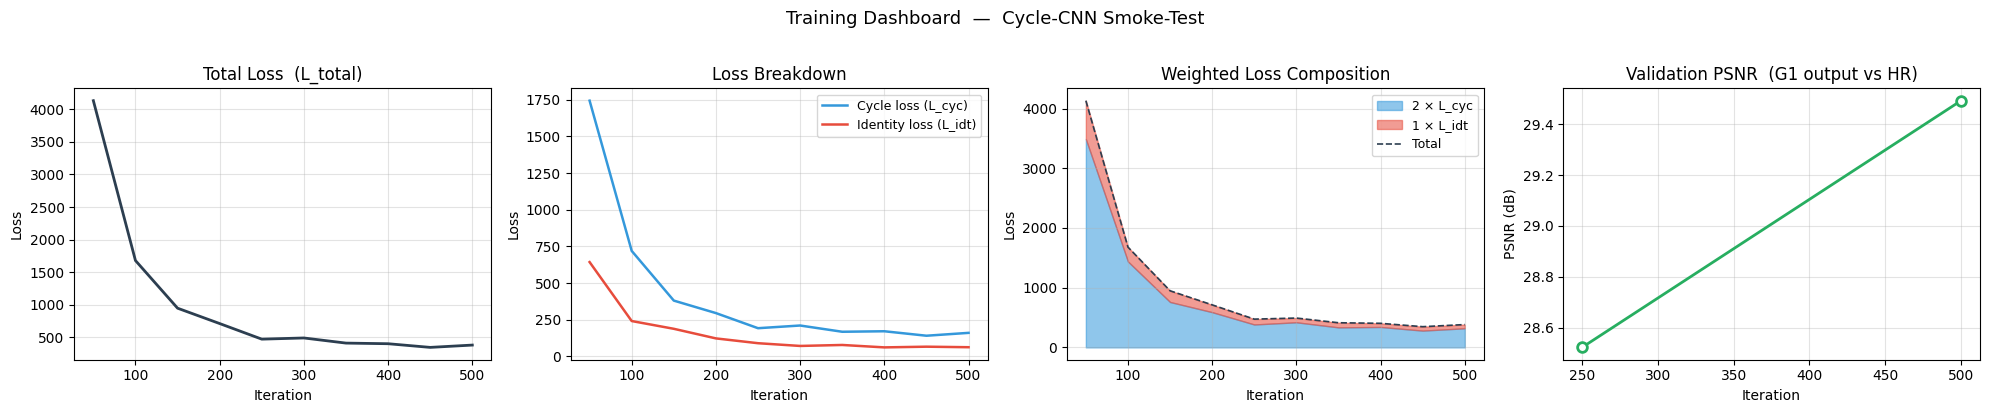

In [9]:
# ── Training Dashboard  (4 panels) ────────────────────────────────────────────
n_panels = 3 if not psnr_log else 4
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4))
fig.suptitle('Training Dashboard  —  Cycle-CNN Smoke-Test', fontsize=13, y=1.02)

# Panel 1 – Total loss
axes[0].plot(iter_log, loss_log, color='#2c3e50', lw=2)
axes[0].set_title('Total Loss  (L_total)')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.35)

# Panel 2 – Cycle vs Identity loss breakdown
axes[1].plot(iter_log, cyc_log, color='#3498db', lw=1.8, label='Cycle loss (L_cyc)')
axes[1].plot(iter_log, idt_log, color='#e74c3c', lw=1.8, label='Identity loss (L_idt)')
axes[1].set_title('Loss Breakdown')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.35)

# Panel 3 – Cycle vs Identity contribution (stacked area)
axes[2].fill_between(iter_log, 0, [2*c for c in cyc_log],
                     alpha=0.55, color='#3498db', label='2 × L_cyc')
axes[2].fill_between(iter_log, [2*c for c in cyc_log],
                     [2*c + d for c, d in zip(cyc_log, idt_log)],
                     alpha=0.55, color='#e74c3c', label='1 × L_idt')
axes[2].plot(iter_log, loss_log, color='#2c3e50', lw=1.2, linestyle='--', label='Total')
axes[2].set_title('Weighted Loss Composition')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Loss')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.35)

# Panel 4 – Validation PSNR over training (only if available)
if psnr_log:
    axes[3].plot(psnr_iter_log, psnr_log, color='#27ae60', lw=2,
                 marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2)
    axes[3].set_title('Validation PSNR  (G1 output vs HR)')
    axes[3].set_xlabel('Iteration'); axes[3].set_ylabel('PSNR (dB)')
    axes[3].grid(alpha=0.35)

plt.tight_layout(); plt.show()

## 6 — Visual Inspection: LR → SR → Cycle-back

Bi-cubic   PSNR=87.78 dB   SSIM=1.0000
Cycle-CNN  PSNR=30.25 dB   SSIM=0.8829
Cycle consistency (G2∘G1 vs LR):  PSNR=29.28 dB


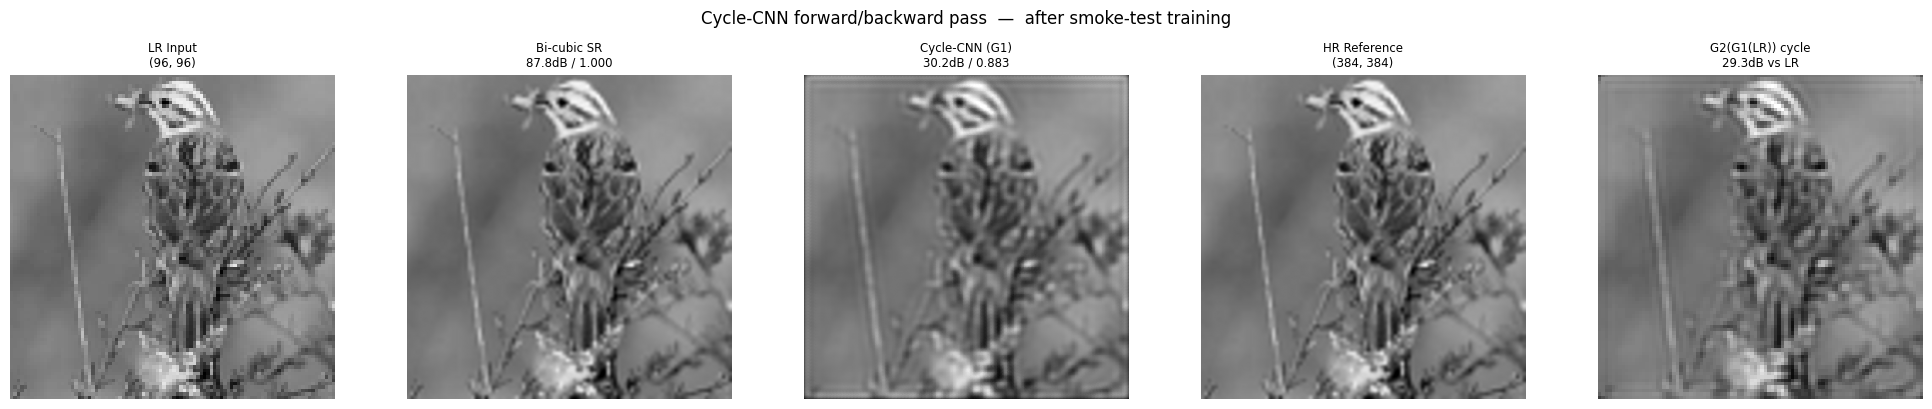

In [10]:
g1.eval(); g2.eval()

lr_t, hr_t = next(iter(test_loader))
lr_t, hr_t = lr_t.to(DEVICE), hr_t.to(DEVICE)

with torch.no_grad():
    sr_t   = g1(lr_t)                        # LR → SR
    lr_rec = g2(sr_t)                         # SR → LR  (forward cycle)
    bic_sr = F.interpolate(lr_t, scale_factor=4, mode='bicubic',
                           align_corners=False, antialias=True).clamp(0, 255)

lr_np, hr_np  = to_np(lr_t), to_np(hr_t)
sr_np, bic_np = to_np(sr_t), to_np(bic_sr)
lr_rec_np     = to_np(lr_rec)

psnr_bic = calc_psnr(bic_np, hr_np);  ssim_bic = calc_ssim(bic_np, hr_np)
psnr_sr  = calc_psnr(sr_np,  hr_np);  ssim_sr  = calc_ssim(sr_np,  hr_np)
psnr_cyc = calc_psnr(lr_rec_np, lr_np)

print(f'Bi-cubic   PSNR={psnr_bic:.2f} dB   SSIM={ssim_bic:.4f}')
print(f'Cycle-CNN  PSNR={psnr_sr:.2f} dB   SSIM={ssim_sr:.4f}')
print(f'Cycle consistency (G2∘G1 vs LR):  PSNR={psnr_cyc:.2f} dB')

panels = [
    (lr_np,     f'LR Input\n{lr_np.shape}'),
    (bic_np,    f'Bi-cubic SR\n{psnr_bic:.1f}dB / {ssim_bic:.3f}'),
    (sr_np,     f'Cycle-CNN (G1)\n{psnr_sr:.1f}dB / {ssim_sr:.3f}'),
    (hr_np,     f'HR Reference\n{hr_np.shape}'),
    (lr_rec_np, f'G2(G1(LR)) cycle\n{psnr_cyc:.1f}dB vs LR'),
]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=8.5); ax.axis('off')
plt.suptitle('Cycle-CNN forward/backward pass  —  after smoke-test training', y=1.01)
plt.tight_layout(); plt.show()

d:\Study\ToR 2026\.venv\Lib\site-packages\skimage\metrics\simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


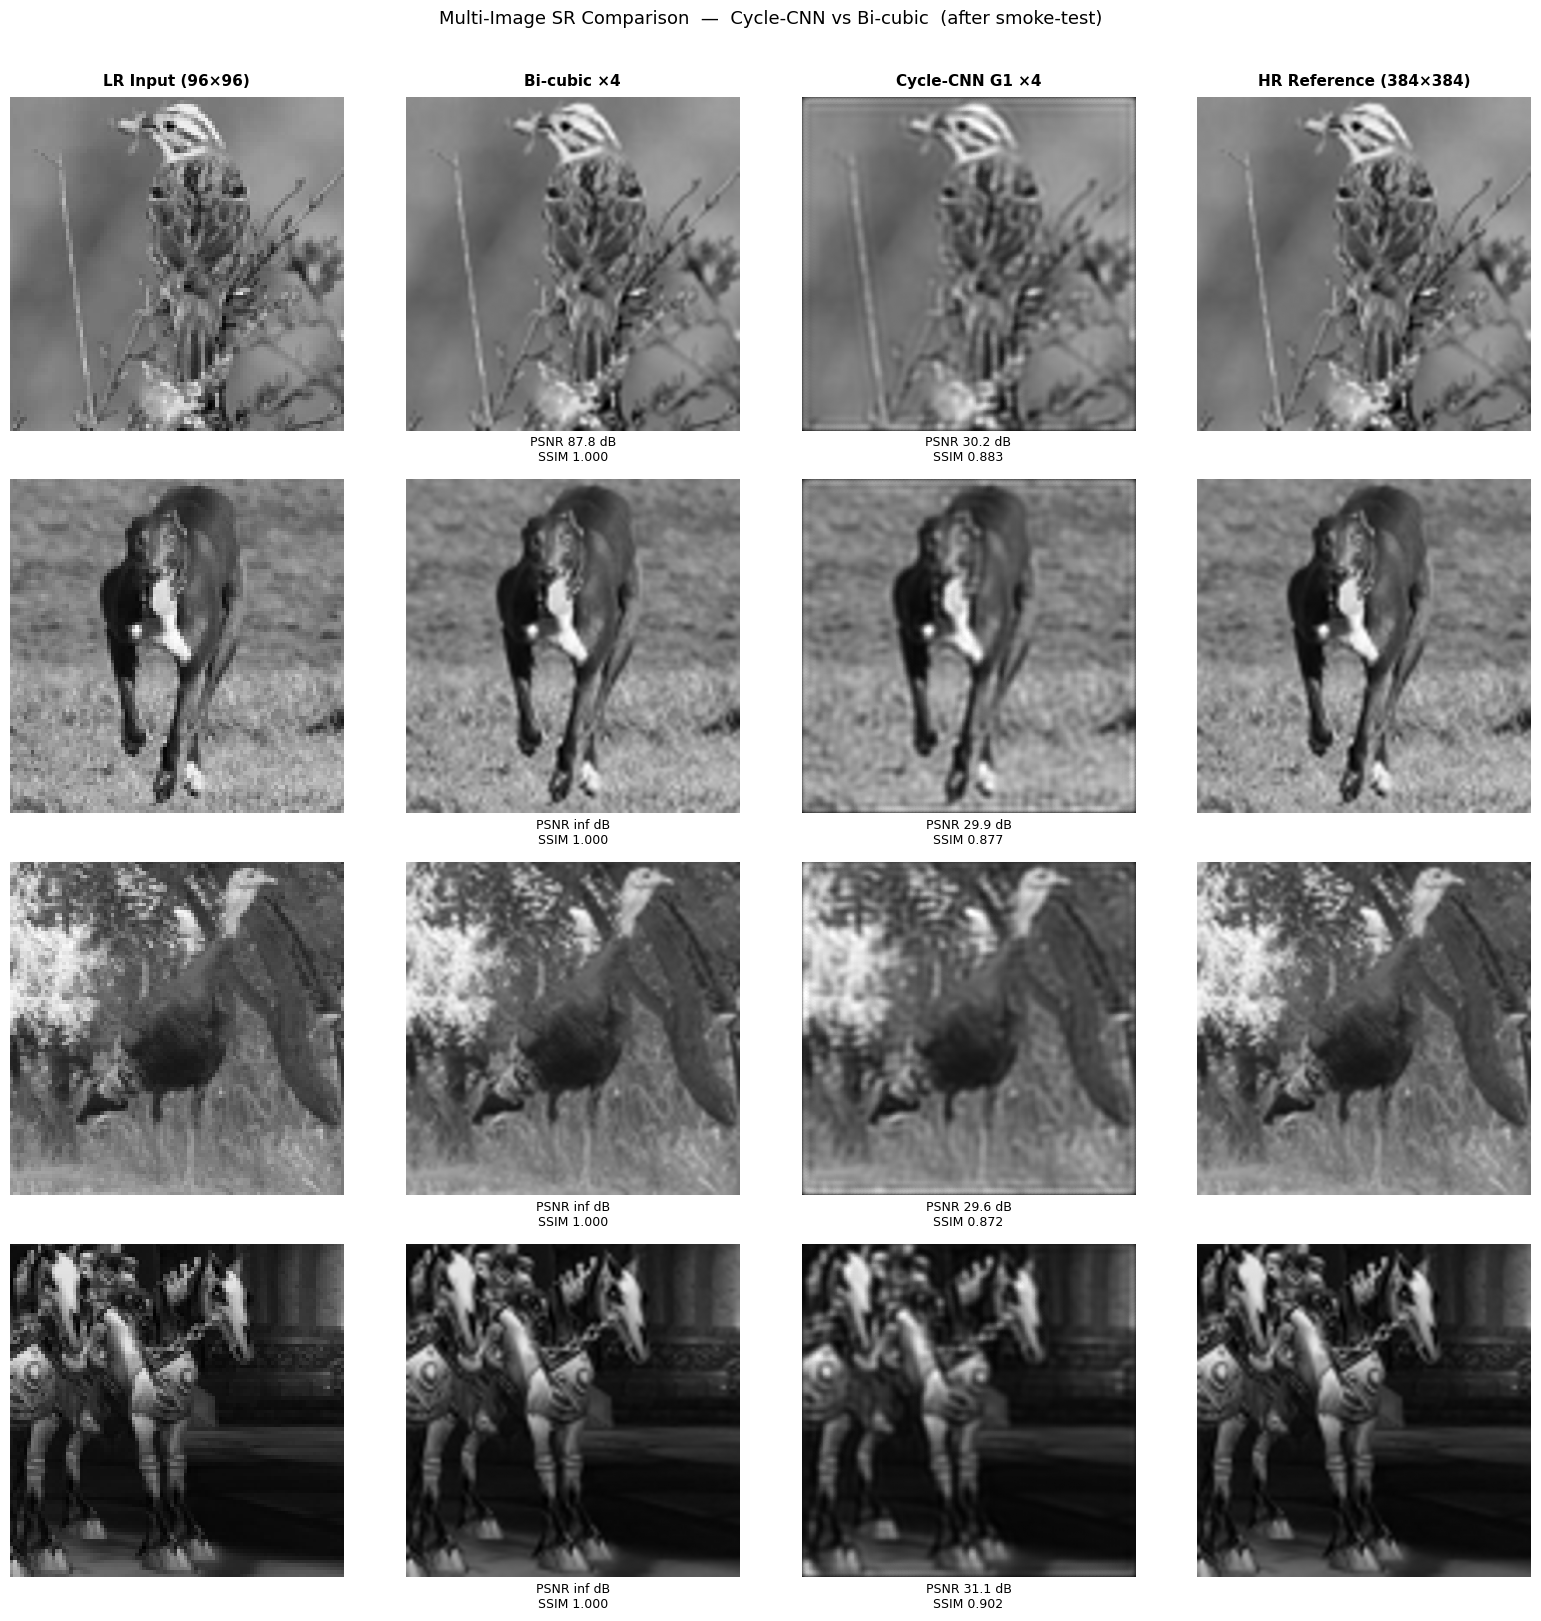

Saved: sr_comparison_grid.png


In [11]:
# ── Multi-image SR comparison grid  (4 test images × 4 columns) ───────────────
# Shows LR input | Bi-cubic SR | Cycle-CNN SR | HR reference for 4 images.
g1.eval(); g2.eval()

N_SHOW = 4
sample_iter = iter(test_loader)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(16, N_SHOW * 4))
col_titles = ['LR Input (96×96)', 'Bi-cubic ×4', 'Cycle-CNN G1 ×4', 'HR Reference (384×384)']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=8)

for row in range(N_SHOW):
    lr_t, hr_t = next(sample_iter)
    lr_t, hr_t = lr_t.to(DEVICE), hr_t.to(DEVICE)

    with torch.no_grad():
        sr_t  = g1(lr_t)
        bic_t = F.interpolate(lr_t, scale_factor=4, mode='bicubic',
                              align_corners=False, antialias=True).clamp(0, 255)

    lr_np  = to_np(lr_t);   hr_np = to_np(hr_t)
    sr_np  = to_np(sr_t);   bic_np = to_np(bic_t)

    psnr_bic = calc_psnr(bic_np, hr_np);  ssim_bic = calc_ssim(bic_np, hr_np)
    psnr_sr  = calc_psnr(sr_np,  hr_np);  ssim_sr  = calc_ssim(sr_np,  hr_np)

    for col, (img, label) in enumerate([
        (lr_np,  ''),
        (bic_np, f'PSNR {psnr_bic:.1f} dB\nSSIM {ssim_bic:.3f}'),
        (sr_np,  f'PSNR {psnr_sr:.1f} dB\nSSIM {ssim_sr:.3f}'),
        (hr_np,  ''),
    ]):
        axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=255)
        if label:
            axes[row, col].set_xlabel(label, fontsize=9)
        axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
        for spine in axes[row, col].spines.values():
            spine.set_visible(False)

fig.suptitle('Multi-Image SR Comparison  —  Cycle-CNN vs Bi-cubic  (after smoke-test)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('sr_comparison_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: sr_comparison_grid.png')

## 7 — Evaluation Table (reproduces Table 1 from paper)

Tests four degradation conditions against Bi-cubic, SRCNN, and Cycle-CNN.

In [12]:
def degrade(lr_np, mode):
    if mode == 'none':      return lr_np.astype(np.float32)
    if mode == 'blur':      return gaussian_filter(lr_np.astype(np.float32), sigma=2.)
    if mode == 'noise':
        rng = np.random.RandomState(0)
        return np.clip(lr_np + rng.normal(0., 10., lr_np.shape), 0, 255).astype(np.float32)
    if mode == 'blur_noise':
        rng = np.random.RandomState(0)
        return np.clip(gaussian_filter(lr_np.astype(np.float32), sigma=2.)
                       + rng.normal(0., 10., lr_np.shape), 0, 255).astype(np.float32)

def bicubic_up4_np(lr_np):
    h, w = lr_np.shape
    return np.array(Image.fromarray(lr_np.astype(np.uint8))
                    .resize((w*4, h*4), Image.BICUBIC), dtype=np.float32)

# Collect up to 8 test images
test_imgs = []
for lr_t, hr_t in test_loader:
    test_imgs.append((to_np(lr_t).astype(np.float32),
                      to_np(hr_t).astype(np.float32)))
    if len(test_imgs) >= 8: break

srcnn = SRCNN().to(DEVICE); srcnn.eval()   # untrained baseline
conditions = ['none', 'blur', 'noise', 'blur_noise']

rows = []
for cond in conditions:
    bic_p, bic_s, src_p, src_s, cyc_p, cyc_s = [], [], [], [], [], []
    for lr_np, hr_np in test_imgs:
        deg = degrade(lr_np, cond)

        # Bi-cubic
        bic = bicubic_up4_np(deg)
        bic_p.append(calc_psnr(bic, hr_np)); bic_s.append(calc_ssim(bic, hr_np))

        # SRCNN (on bi-cubic upsampled input)
        inp = torch.from_numpy(bic).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): src_out = srcnn(inp)
        src = to_np(src_out).astype(np.float32)[:hr_np.shape[0], :hr_np.shape[1]]
        src_p.append(calc_psnr(src, hr_np)); src_s.append(calc_ssim(src, hr_np))

        # Cycle-CNN G1
        inp = torch.from_numpy(deg).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad(): cyc_out = g1(inp)
        cyc = to_np(cyc_out).astype(np.float32)[:hr_np.shape[0], :hr_np.shape[1]]
        cyc_p.append(calc_psnr(cyc, hr_np)); cyc_s.append(calc_ssim(cyc, hr_np))

    avg = lambda lst: sum(lst)/len(lst)
    rows.append((cond, avg(bic_p), avg(bic_s), avg(src_p), avg(src_s), avg(cyc_p), avg(cyc_s)))

# ── Print table ────────────────────────────────────────────────────────────────
print(f'{"Degradation":<12} {"Bi-cubic":>14} {"SRCNN":>14} {"Cycle-CNN (ours)":>18}')
print(f'{"":12} {"PSNR":>7} {"SSIM":>6} {"PSNR":>7} {"SSIM":>6} {"PSNR":>8} {"SSIM":>9}')
print('─' * 70)
for cond, bp, bs, sp, ss, cp, cs in rows:
    cond_lbl = {'none':'None','blur':'Blur','noise':'Noise','blur_noise':'Blur+Noise'}[cond]
    print(f'{cond_lbl:<12} {bp:7.2f} {bs:6.4f} {sp:7.2f} {ss:6.4f} {cp:8.2f} {cs:9.4f}')

Degradation        Bi-cubic          SRCNN   Cycle-CNN (ours)
                PSNR   SSIM    PSNR   SSIM     PSNR      SSIM
──────────────────────────────────────────────────────────────────────
None           51.28 0.9982    6.66 0.0297    29.49    0.8649
Blur           22.53 0.5866    6.66 0.0297    22.16    0.5677
Noise          30.12 0.7906    6.66 0.0297    27.84    0.7800
Blur+Noise     21.79 0.4228    6.66 0.0297    21.79    0.4929


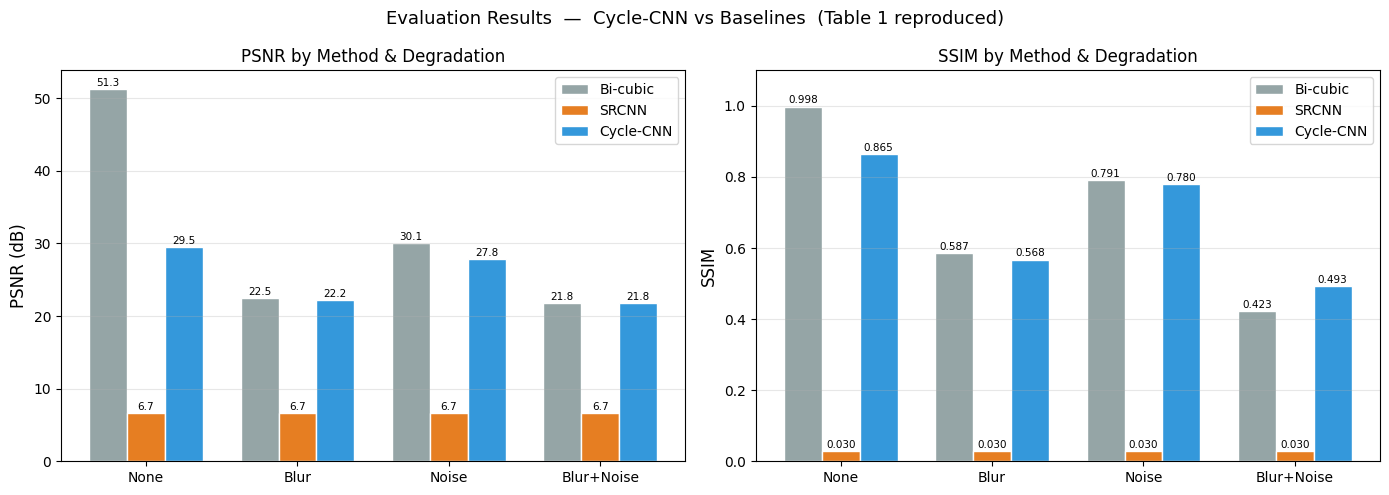

Saved: eval_bar_chart.png


In [13]:
# ── Bar chart: PSNR & SSIM by method × degradation condition ──────────────────
cond_labels  = ['None', 'Blur', 'Noise', 'Blur+Noise']
method_names = ['Bi-cubic', 'SRCNN', 'Cycle-CNN']
colors       = ['#95a5a6', '#e67e22', '#3498db']

psnr_by_method = [
    [r[1] for r in rows],   # Bi-cubic PSNR
    [r[3] for r in rows],   # SRCNN PSNR
    [r[5] for r in rows],   # Cycle-CNN PSNR
]
ssim_by_method = [
    [r[2] for r in rows],
    [r[4] for r in rows],
    [r[6] for r in rows],
]

x     = np.arange(len(cond_labels))
width = 0.25

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluation Results  —  Cycle-CNN vs Baselines  (Table 1 reproduced)',
             fontsize=13)

for i, (name, psnrs, c) in enumerate(zip(method_names, psnr_by_method, colors)):
    bars = ax1.bar(x + i*width, psnrs, width, label=name, color=c, edgecolor='white')
    for b in bars:
        ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.15,
                 f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=7.5)

ax1.set_xticks(x + width); ax1.set_xticklabels(cond_labels)
ax1.set_ylabel('PSNR (dB)', fontsize=12)
ax1.set_title('PSNR by Method & Degradation')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

for i, (name, ssims, c) in enumerate(zip(method_names, ssim_by_method, colors)):
    bars = ax2.bar(x + i*width, ssims, width, label=name, color=c, edgecolor='white')
    for b in bars:
        ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                 f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax2.set_xticks(x + width); ax2.set_xticklabels(cond_labels)
ax2.set_ylabel('SSIM', fontsize=12)
ax2.set_title('SSIM by Method & Degradation')
ax2.legend(); ax2.grid(axis='y', alpha=0.3); ax2.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('eval_bar_chart.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: eval_bar_chart.png')

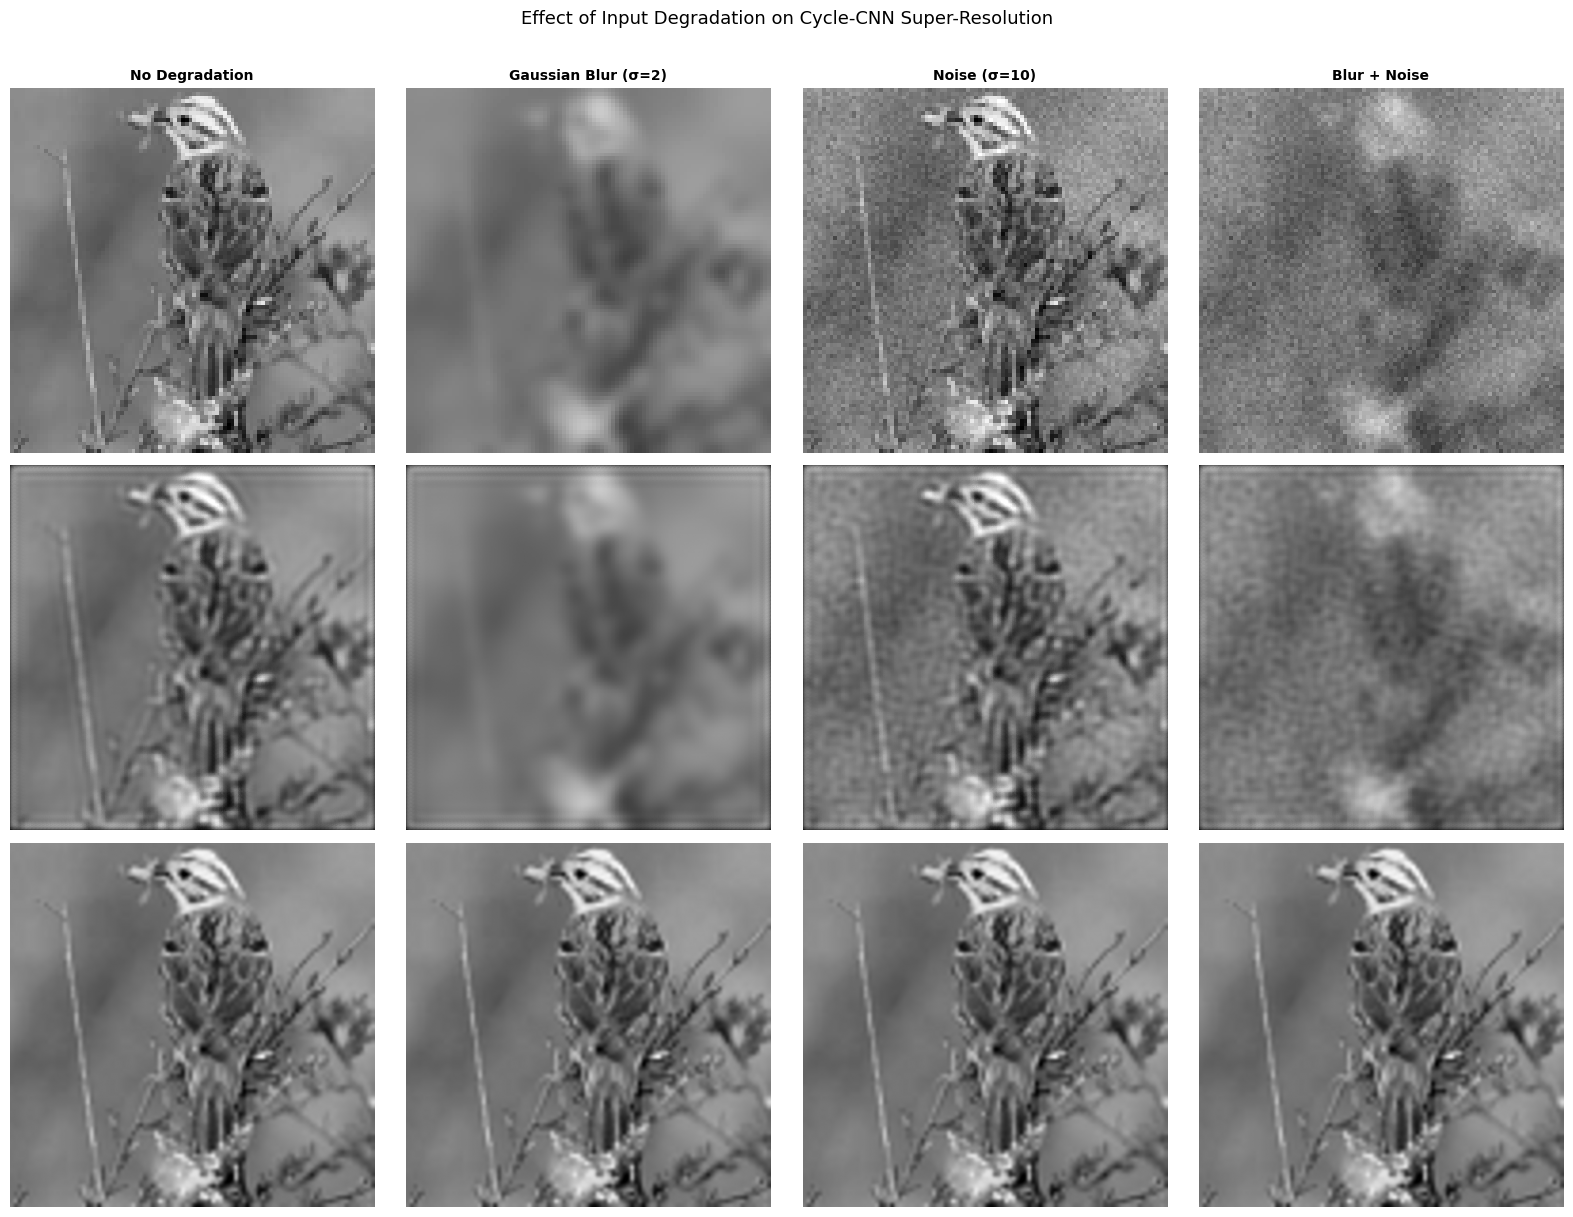

Saved: degradation_comparison.png


In [14]:
# ── Degradation effect on the same test image + Cycle-CNN SR ──────────────────
# Shows how each input degradation looks and how G1 recovers from it.
g1.eval()

lr_sample, hr_sample = test_imgs[0]   # float32 numpy
hr_tensor = torch.from_numpy(hr_sample).unsqueeze(0).unsqueeze(0).to(DEVICE)

cond_show  = ['none', 'blur', 'noise', 'blur_noise']
cond_label = ['No Degradation', 'Gaussian Blur (σ=2)', 'Noise (σ=10)', 'Blur + Noise']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
row_titles = ['Degraded LR Input  (96×96)',
              'Cycle-CNN SR Output  (384×384)',
              'HR Reference  (384×384)']

for row, rtitle in enumerate(row_titles):
    axes[row, 0].set_ylabel(rtitle, fontsize=10, fontweight='bold', labelpad=8)

for col, (cond, clabel) in enumerate(zip(cond_show, cond_label)):
    deg = degrade(lr_sample, cond)                          # degraded LR

    # Row 0 – degraded LR (shown at native 96×96 size)
    axes[0, col].imshow(deg, cmap='gray', vmin=0, vmax=255)
    axes[0, col].set_title(clabel, fontsize=10, fontweight='bold')
    axes[0, col].axis('off')

    # Row 1 – Cycle-CNN SR output
    with torch.no_grad():
        inp = torch.from_numpy(deg).unsqueeze(0).unsqueeze(0).to(DEVICE)
        sr  = g1(inp)
    sr_np = to_np(sr)
    p = calc_psnr(sr_np.astype(np.float32), hr_sample)
    s = calc_ssim(sr_np.astype(np.float32), hr_sample)
    axes[1, col].imshow(sr_np, cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_xlabel(f'PSNR {p:.1f} dB  /  SSIM {s:.3f}', fontsize=9)
    axes[1, col].axis('off')

    # Row 2 – HR reference (same for all columns)
    axes[2, col].imshow(hr_sample, cmap='gray', vmin=0, vmax=255)
    axes[2, col].axis('off')

fig.suptitle('Effect of Input Degradation on Cycle-CNN Super-Resolution',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('degradation_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: degradation_comparison.png')